In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import datetime
import seaborn as sns
from geopy.distance import distance
import geopandas as gpd
import rioxarray

from functools import reduce
import seaborn as sns
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore')

In [39]:
'''
# read in example ECHAM flow data
file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ens01_197901-201902.nc'
file_path = '../../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ens01/' + file_name
example_echam = xr.open_dataset(file_path)['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
echam_gridarea = xr.open_dataset('/nesi/project/niwa00015/queenle/data/netcdfs/ECHAM_cellarea.nc')['cell_area']
merge = xr.merge([example_echam,echam_gridarea])
echam_da = merge.assign(converted = lambda merge: merge.mrro * merge.cell_area)
'''

file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ensmean_197901-201902.nc'
file_path = '../../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ensmean/' + file_name
echam_mean = xr.open_dataset(file_path)['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
echam_gridarea = xr.open_dataset('/nesi/project/niwa00015/queenle/data/netcdfs/ECHAM_cellarea.nc')['cell_area']
merge = xr.merge([example_echam,echam_gridarea])
echam_da = merge.assign(converted = lambda merge: merge.mrro * merge.cell_area)

# interpolate model data
new_lon = np.linspace(echam_da.lon[0], echam_da.lon[-1], len(echam_da.lon.values) * 10)
new_lat = np.linspace(echam_da.lat[0], echam_da.lat[-1], len(echam_da.lat.values) * 10)
da_interp = echam_da.interp(lat=new_lat, lon=new_lon,method='linear')
da_interp.rio.set_crs("EPSG:4326")
da_interp.rio.set_spatial_dims('lon', 'lat', inplace=True)

# read in site metadata
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

flow_df = pd.read_csv("/nesi/project/niwa00015/queenle/data/flows/seasonal/40_50yrs/40plus.csv")
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")
catchment_data = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]
catchment_data.index = catchment_data['SITE']

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]

subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                           geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                           crs='EPSG:4326')


In [83]:
file_name = 'mrro_Lmon-ANZ_ECHAM5-4_All-Hist_est1_v1-0_ensmean_197901-201902.nc'
file_path = '../../stoneda/data-for-laura/C20C/NOAA-ESRLandCIRES/ECHAM5-4/All-Hist/est1/v1-0/mon/land-ANZ/mrro/ensmean/' + file_name
echam_mean = xr.open_dataset(file_path)['mrro'].sel(time=slice('1979-03-01','2019-03-01')).resample(time='QS-DEC').mean()
echam_gridarea = xr.open_dataset('/nesi/project/niwa00015/queenle/data/netcdfs/ECHAM_cellarea.nc')['cell_area']
merge = xr.merge([echam_mean,echam_gridarea])
echam_da = merge.assign(converted = lambda merge: merge.mrro * merge.cell_area)

# interpolate model data
new_lon = np.linspace(echam_da.lon[0], echam_da.lon[-1], len(echam_da.lon.values) * 10)
new_lat = np.linspace(echam_da.lat[0], echam_da.lat[-1], len(echam_da.lat.values) * 10)
da_interp = echam_da.interp(lat=new_lat, lon=new_lon,method='linear')
da_interp.rio.set_crs("EPSG:4326")
da_interp.rio.set_spatial_dims('lon', 'lat', inplace=True)


<xarray.Dataset>
Dimensions:    (lat: 260, lon: 230, time: 160)
Coordinates:
  * time       (time) datetime64[ns] 1979-03-01 1979-06-01 ... 2018-12-01
  * lat        (lat) float64 -31.81 -31.88 -31.95 ... -50.38 -50.45 -50.52
  * lon        (lon) float64 164.2 164.3 164.4 164.5 ... 180.5 180.6 180.7 180.8
Data variables:
    mrro       (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    cell_area  (lat, lon) float64 5.898e+09 5.898e+09 ... 4.413e+09 4.413e+09
    converted  (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [4]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
catchments_df_ae = catchments_df.to_crs(crs_proj4)
meta_df_ae = meta_df.to_crs(crs_proj4)


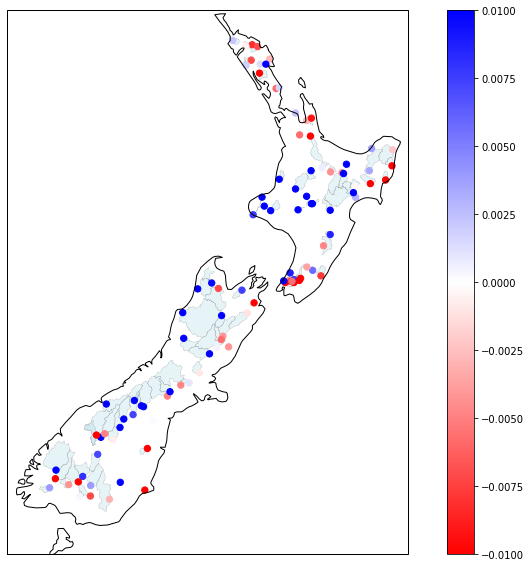

In [102]:
import pymannkendall as mk


fig, axs = plt.subplots(1,1, subplot_kw={'projection': crs},figsize=(14,10))
catchments_df_ae.plot(ax=axs,color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.3)

winter_79_2019 = flow_df[flow_df.index.month == 6]['1969':'2019']

lats = []
lons = []
slopes = []

for site in winter_79_2019:
    
    ts = winter_79_2019[site]

    ts = ts.dropna()
    norm_ts = (((ts - ts.mean()))/ts.std()).values
    #print(norm_time_series.std())

    lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
    lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]

    trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(norm_ts)

    lats.append(lat)
    lons.append(lon)
    
    slopes.append(slope)

im = axs.scatter(lons,lats,c=slopes,cmap='bwr_r',marker='o',s=40,vmin=-0.01,vmax=0.01)#,edgecolor='black')
cbar = fig.colorbar(im)

axs.coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
axs.set_xlim([18500000,19900000])
axs.set_ylim([-5950000,-4050000])

plt.savefig("obs_streamflow_trends.png",dpi=300)

<xarray.DataArray 'mrro' (time: 40, lat: 260, lon: 230)>
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * time     (time) datetime64[ns] 1979-06-01 1980-06-01 ... 2018-06-01
  * lat      (lat) float64 -31.81 -31.88 -31.95 -32.03 ... -50.38 -50.45 -50.52
  * lon      (lon) float64 164.2 164.3 164.4 164.5 ... 180.5 180.6 180.7 180.8

In [40]:
catchment_data

,SITE,LOC,nzreach,CATCHAREA,poly_area,geometry
SITE,,,,,,
93203.0,93203.0,Buller at Te Kuha -Ratings,12012479.0,6.305577e+09,6306.083103,"POLYGON ((171.57589 -42.03907, 171.57590 -42.0..."
79704.0,79704.0,Lake Te Anau at Park HQ -Lake,15022519.0,3.082281e+09,3082.321796,"POLYGON ((167.31972 -45.27404, 167.31974 -45.2..."
75292.0,75292.0,Lake Wanaka at Roys Bay -River,14012580.0,2.576090e+09,2576.405698,"POLYGON ((168.61704 -44.50319, 168.61706 -44.5..."
68526.0,68526.0,Rakaia at Fighting Hill -River,13045745.0,2.555512e+09,2555.510399,"POLYGON ((170.80083 -43.30959, 170.80084 -43.3..."
21801.0,21801.0,Mohaka at Raupunga -River leve,8014348.0,2.363425e+09,2363.781601,"MULTIPOLYGON (((176.14129 -39.04355, 176.14128..."
...,...,...,...,...,...,...
3506.0,3506.0,Maungaparerua at Tyrees Ford -,1006650.0,1.170900e+07,11.709000,"POLYGON ((173.82432 -35.22346, 173.82465 -35.2..."
45702.0,45702.0,Waiwhiu at Dome Shadow -River,2001422.0,8.475426e+06,8.474400,"POLYGON ((174.63065 -36.34979, 174.63064 -36.3..."
31101.0,31101.0,Taupo at Flax Swamp -River lev,9009031.0,8.365500e+06,8.365501,"POLYGON ((174.86108 -41.04771, 174.86144 -41.0..."


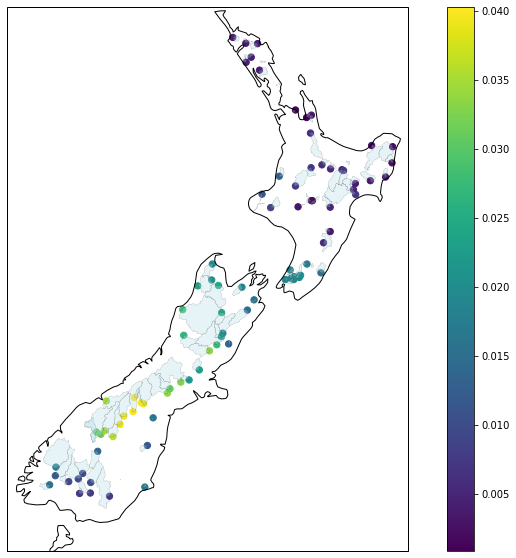

In [126]:
fig, axs = plt.subplots(1,1, subplot_kw={'projection': crs},figsize=(14,10))

winter_converted = da_interp.sel(time=da_interp.time.dt.month.isin([6])).converted
winter_converted.rio.set_crs("EPSG:4326")
winter_converted.rio.set_spatial_dims('lon', 'lat', inplace=True)

lats = []
lons = []
slopes = []

for site in winter_79_2019:
    
    #print(site)
    if site in ['15453','74368','39508','45702','3506','29841','4901','29244',
                '33347','36001','19734','46641','6501','1443499','31101','5528']:
        continue

    catchment_site = catchment_data.loc[float(site)]
    clipped = winter_converted.rio.clip([catchment_site.geometry],catchment_data.crs)

    ts = clipped.mean(['lat','lon'])
    
    norm_ts = (((ts - ts.mean()))/ts.std()).values

    lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
    lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]

    trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(norm_ts)

    lats.append(lat)
    lons.append(lon)
    slopes.append(slope)

im = axs.scatter(lons,lats,c=slopes,cmap='viridis',marker='o',alpha=1,s=40)#,vmin=-0.01,vmax=0.01,edgecolor='black')
cbar = fig.colorbar(im)

catchments_df_ae.plot(ax=axs,color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.3)
axs.coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
axs.set_xlim([18500000,19900000])
axs.set_ylim([-5950000,-4050000])

plt.savefig("ECHAM5_runoff_trends.png",dpi=300)

(-5950000, -4050000)

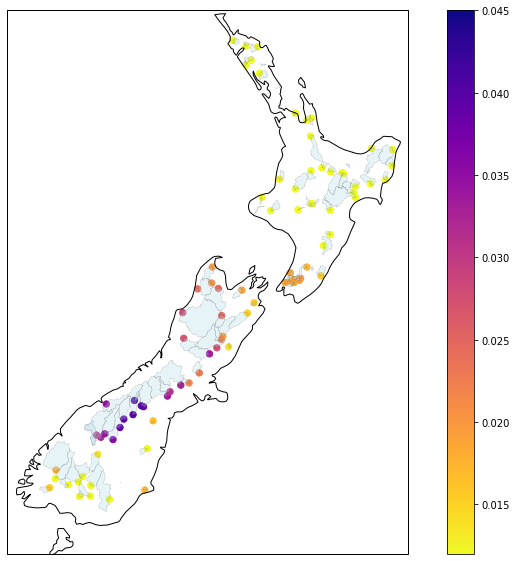

In [109]:
fig, axs = plt.subplots(1,1, subplot_kw={'projection': crs},figsize=(14,10))

im = axs.scatter(lons,lats,c=slopes,cmap='plasma_r',marker='o',alpha=1,s=40,vmin=0.012,vmax=0.045)#,edgecolor='black')
cbar = fig.colorbar(im)

catchments_df_ae.plot(ax=axs,color='lightblue',edgecolor='black',linewidth=0.2,alpha=0.3)
axs.coastlines(resolution='50m', color='black',linewidth=1,zorder = 1)
axs.set_xlim([18500000,19900000])
axs.set_ylim([-5950000,-4050000])

#plt.savefig("ECHAM5_runoff_trends.png",dpi=300)

In [90]:
lons

[18976633.595529348,
 19320610.82208056,
 19352893.47441061,
 19232668.424353875,
 18944350.943199296,
 19628965.81157793,
 18764013.368114192,
 19773681.149609182,
 18748428.63940313,
 19562174.117101964,
 18907615.511237513,
 18968841.231173817,
 19450854.62630869,
 19844925.62371688,
 19847152.013532747,
 19253819.127604596,
 19288328.16975051,
 19381836.542016864,
 19507627.56661326,
 19559947.7272861,
 18869766.8843678,
 19135820.46736373,
 19605588.718511343,
 18752881.419034865,
 19060123.213624302,
 19362912.228582002,
 18827465.47786636,
 19630079.00648586,
 19106877.399757475,
 19217083.695642818,
 19600022.743971676,
 19339535.135515414,
 18981086.375161078,
 19492042.837902203,
 19249366.347972862,
 19670154.02317144,
 19248253.153064933,
 19335082.355883688,
 19116896.153928872,
 18648241.09768919,
 19502061.592073597,
 19502061.592073597,
 19596683.15924788,
 19716908.209304616,
 19171442.704417575,
 19507627.56661326,
 19420798.36379451,
 19563287.312009897,
 18715032.79

In [132]:
winter = echam_da.sel(time=echam_da.time.dt.month.isin([6])).mrro

In [133]:
polyfit = winter.polyfit('time',1)

In [134]:
fit = polyfit.sel(degree=1).polyfit_coefficients.where(polyfit.polyfit_coefficients != 0)

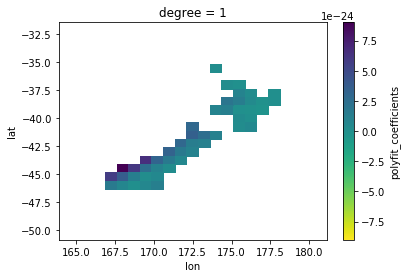

In [135]:
fit.sel(degree=1).plot(cmap='viridis_r')

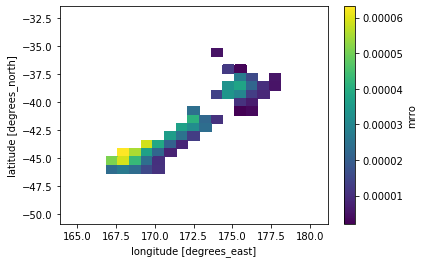

In [136]:
mean_time = winter.mean('time')
mean_time.where(mean_time!=0).plot()

In [131]:
echam_gridarea

<xarray.DataArray 'cell_area' (lat: 26, lon: 23)>
array([[5.898063e+09, 5.898063e+09, 5.898063e+09, ..., 5.898063e+09,
        5.898063e+09, 5.898063e+09],
       [5.849758e+09, 5.849758e+09, 5.849758e+09, ..., 5.849758e+09,
        5.849758e+09, 5.849758e+09],
       [5.800469e+09, 5.800469e+09, 5.800469e+09, ..., 5.800469e+09,
        5.800469e+09, 5.800469e+09],
       ...,
       [4.551181e+09, 4.551181e+09, 4.551181e+09, ..., 4.551181e+09,
        4.551181e+09, 4.551181e+09],
       [4.482336e+09, 4.482336e+09, 4.482336e+09, ..., 4.482336e+09,
        4.482336e+09, 4.482336e+09],
       [4.412738e+09, 4.412738e+09, 4.412738e+09, ..., 4.412738e+09,
        4.412738e+09, 4.412738e+09]])
Coordinates:
  * lon      (lon) float32 164.2 165.0 165.8 166.5 ... 178.5 179.2 180.0 180.8
  * lat      (lat) float32 -31.81 -32.56 -33.31 -34.05 ... -49.02 -49.77 -50.52
Attributes:
    standard_name:  area
    long_name:      area of grid cell
    units:          m2